# 01 - PortWatch dataset exploration

This notebook contains the first exploratory analysis of the PortWatch maritime chokepoints dataset. The goal is to understand the raw data before building features, models, and closure scenarios.

## 1. Load the dataset

The raw CSV is stored in `data/raw/`. Each row corresponds to one daily observation for one maritime chokepoint.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
raw_path = ROOT / 'data' / 'raw' / 'portwatch_daily_chokepoints.csv'
if not raw_path.exists():
    ROOT = Path('..').resolve()
    raw_path = ROOT / 'data' / 'raw' / 'portwatch_daily_chokepoints.csv'
df = pd.read_csv(raw_path, parse_dates=['date'])

df.shape

(74844, 17)

In [2]:
df.head()

,date,portid,portname,n_container,n_dry_bulk,n_general_cargo,n_roro,n_tanker,n_cargo,n_total,capacity_container,capacity_dry_bulk,capacity_general_cargo,capacity_roro,capacity_tanker,capacity_cargo,capacity
0,2019-01-01,chokepoint1,Suez Canal,15,15,7,4,18,41,59,1018466,618654,111545,21900,1279775,1770567,3050342
1,2019-01-02,chokepoint1,Suez Canal,24,4,6,6,10,40,50,1534924,227315,8536,37934,518306,1808711,2327017
2,2019-01-03,chokepoint1,Suez Canal,13,14,9,2,23,38,61,555097,977689,39398,10829,804257,1583014,2387272
3,2019-01-04,chokepoint1,Suez Canal,17,11,2,2,14,32,46,1044184,430139,3673,3430,759384,1481428,2240812
4,2019-01-05,chokepoint1,Suez Canal,20,9,1,1,13,31,44,1218925,777548,4587,5567,628481,2006627,2635108


## 2. Basic structure

This section checks the available columns, the observation period, and the number of chokepoints in the dataset.

In [3]:
pd.DataFrame({
    'column': df.columns,
    'dtype': [str(dtype) for dtype in df.dtypes],
    'missing_values': df.isna().sum().values,
    'missing_rate': (df.isna().mean().values * 100).round(2),
})

,column,dtype,missing_values,missing_rate
0,date,datetime64[ns],0,0.0
1,portid,object,0,0.0
2,portname,object,0,0.0
3,n_container,int64,0,0.0
4,n_dry_bulk,int64,0,0.0
5,n_general_cargo,int64,0,0.0
6,n_roro,int64,0,0.0
7,n_tanker,int64,0,0.0
8,n_cargo,int64,0,0.0
9,n_total,int64,0,0.0


In [4]:
overview = {
    'start_date': df['date'].min(),
    'end_date': df['date'].max(),
    'rows': len(df),
    'chokepoints': df['portname'].nunique(),
}
overview

{'start_date': Timestamp('2019-01-01 00:00:00'),
 'end_date': Timestamp('2026-04-26 00:00:00'),
 'rows': 74844,
 'chokepoints': 28}

In [5]:
sorted(df['portname'].dropna().unique())

['Bab el-Mandeb Strait',
 'Balabac Strait',
 'Bering Strait',
 'Bohai Strait',
 'Bosporus Strait',
 'Cape of Good Hope',
 'Dover Strait',
 'Gibraltar Strait',
 'Kerch Strait',
 'Korea Strait',
 'Lombok Strait',
 'Luzon Strait',
 'Magellan Strait',
 'Makassar Strait',
 'Malacca Strait',
 'Mindoro Strait',
 'Mona Passage',
 'Ombai Strait',
 'Oresund Strait',
 'Panama Canal',
 'Strait of Hormuz',
 'Suez Canal',
 'Sunda Strait',
 'Taiwan Strait',
 'Torres Strait',
 'Tsugaru Strait',
 'Windward Passage',
 'Yucatan Channel']

## 3. Traffic by chokepoint

The first business question is: which chokepoints have the highest observed maritime traffic?

In [6]:
traffic_summary = (
    df.groupby('portname')
    .agg(
        mean_total_ships=('n_total', 'mean'),
        mean_tankers=('n_tanker', 'mean'),
        mean_cargo=('n_cargo', 'mean'),
        observed_days=('date', 'nunique'),
    )
    .sort_values('mean_total_ships', ascending=False)
)
traffic_summary.head(10).round(2)

,mean_total_ships,mean_tankers,mean_cargo,observed_days
portname,,,,
Taiwan Strait,241.35,55.43,185.92,2673
Korea Strait,223.22,61.69,161.54,2673
Malacca Strait,196.89,75.28,121.61,2673
Bohai Strait,175.01,36.36,138.65,2673
Dover Strait,165.90,57.91,108.00,2673
Gibraltar Strait,130.79,42.97,87.82,2673
Bosporus Strait,95.59,23.28,72.31,2673
Strait of Hormuz,87.09,52.24,34.86,2673
Luzon Strait,70.15,24.29,45.86,2673


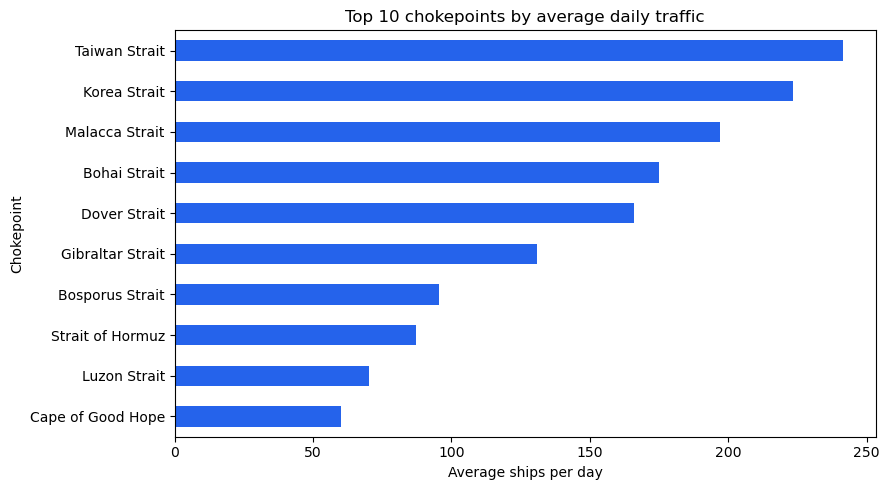

In [7]:
top_10 = traffic_summary.head(10).sort_values('mean_total_ships')
ax = top_10['mean_total_ships'].plot(kind='barh', figsize=(9, 5), color='#2563eb')
ax.set_title('Top 10 chokepoints by average daily traffic')
ax.set_xlabel('Average ships per day')
ax.set_ylabel('Chokepoint')
plt.tight_layout()

## 4. Tanker exposure

Tankers are important for the business case because they are linked to energy flows. A chokepoint can be strategic even if its total traffic is not the highest.

In [8]:
tanker_summary = traffic_summary.sort_values('mean_tankers', ascending=False)
tanker_summary[['mean_total_ships', 'mean_tankers', 'observed_days']].head(10).round(2)

,mean_total_ships,mean_tankers,observed_days
portname,,,
Malacca Strait,196.89,75.28,2673
Korea Strait,223.22,61.69,2673
Dover Strait,165.90,57.91,2673
Taiwan Strait,241.35,55.43,2673
Strait of Hormuz,87.09,52.24,2673
Gibraltar Strait,130.79,42.97,2673
Bohai Strait,175.01,36.36,2673
Luzon Strait,70.15,24.29,2673
Bosporus Strait,95.59,23.28,2673


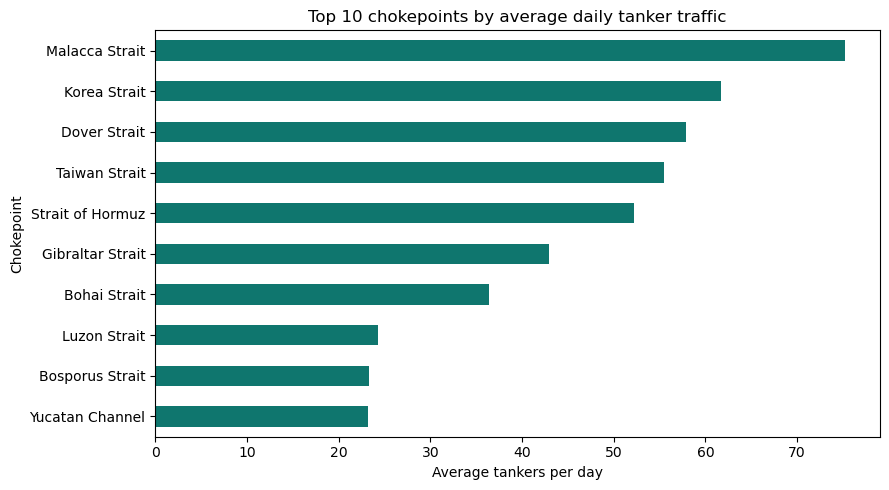

In [9]:
top_tankers = tanker_summary.head(10).sort_values('mean_tankers')
ax = top_tankers['mean_tankers'].plot(kind='barh', figsize=(9, 5), color='#0f766e')
ax.set_title('Top 10 chokepoints by average daily tanker traffic')
ax.set_xlabel('Average tankers per day')
ax.set_ylabel('Chokepoint')
plt.tight_layout()

## 5. Focus on selected strategic chokepoints

The project will focus especially on the Strait of Hormuz, Malacca Strait, and Taiwan Strait because they represent different forms of maritime risk: energy exposure, global trade volume, and regional strategic tension.

In [10]:
focus_ports = ['Strait of Hormuz', 'Malacca Strait', 'Taiwan Strait']
focus = df[df['portname'].isin(focus_ports)].copy()

focus.groupby('portname').agg(
    mean_total_ships=('n_total', 'mean'),
    mean_tankers=('n_tanker', 'mean'),
    min_total_ships=('n_total', 'min'),
    max_total_ships=('n_total', 'max'),
    observed_days=('date', 'nunique'),
).round(2)

,mean_total_ships,mean_tankers,min_total_ships,max_total_ships,observed_days
portname,,,,,
Malacca Strait,196.89,75.28,101,295,2673
Strait of Hormuz,87.09,52.24,0,138,2673
Taiwan Strait,241.35,55.43,7,472,2673


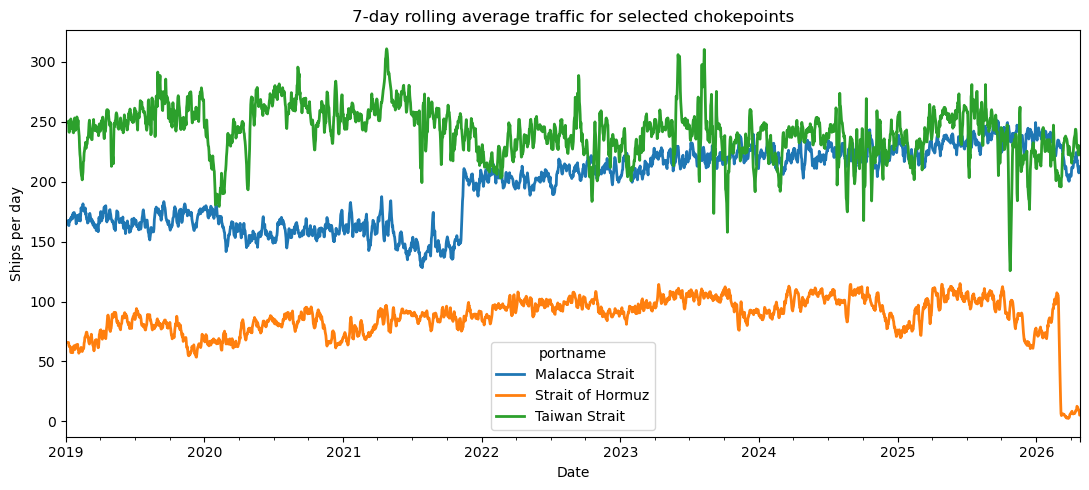

In [11]:
pivot_focus = focus.pivot_table(index='date', columns='portname', values='n_total', aggfunc='mean')
ax = pivot_focus.rolling(7).mean().plot(figsize=(11, 5), linewidth=2)
ax.set_title('7-day rolling average traffic for selected chokepoints')
ax.set_xlabel('Date')
ax.set_ylabel('Ships per day')
plt.tight_layout()

## First observations

- Malacca Strait has very high total traffic and tanker traffic, which makes it a major global chokepoint.
- The Strait of Hormuz has lower total traffic than Malacca, but a high tanker exposure, making it highly strategic for energy flows.
- Taiwan Strait and Korea Strait are among the most active routes in the dataset.
- The next step is to transform these observations into features that can support a criticality score and later modeling.

## 6. Model Training

Following the exploration, we prepare the data and train the classification models (Logistic Regression, Random Forest, Gradient Boosting) to predict the criticality class. Below is the detailed code from `train_models.py` adapted for this notebook.

In [12]:
import sys
from pathlib import Path
import joblib
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd().parent))

from src.config import MODELS, RANDOM_STATE, ensure_directories
from src.data import load_dataset_split
from src.metrics import compute_metrics

# Load data
X_train, X_test, y_train, y_test = load_dataset_split()
print("Data loaded. Training set size:", X_train.shape)

Data loaded. Training set size: (1848, 17)


In [13]:
def build_models() -> dict:
    return {
        "log_reg": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
        ]),
        "random_forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "gradient_boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    }

models = build_models()
print("Models initialized:", list(models.keys()))

Models initialized: ['log_reg', 'random_forest', 'gradient_boosting']


In [14]:
import pandas as pd

metrics_list = []
ensure_directories()

for key, model in models.items():
    print(f"\nTraining {key}...")
    model.fit(X_train, y_train)
    
    # Save model as in original script
    # path = MODELS[key]["path"]
    # joblib.dump(model, path)
    
    # Evaluate
    y_pred = model.predict(X_test)
    metrics = compute_metrics(y_test, y_pred)
    metrics["model"] = key
    metrics_list.append(metrics)
    print(f"{key} training complete.")

df_metrics = pd.DataFrame(metrics_list)
display(df_metrics[["model", "accuracy", "f1_macro", "precision_macro", "recall_macro"]])


Training log_reg...
log_reg training complete.

Training random_forest...
random_forest training complete.

Training gradient_boosting...
gradient_boosting training complete.


,model,accuracy,f1_macro,precision_macro,recall_macro
0,log_reg,0.959416,0.959414,0.959751,0.959416
1,random_forest,0.956169,0.956123,0.956442,0.956169
2,gradient_boosting,0.964286,0.964188,0.964262,0.964286


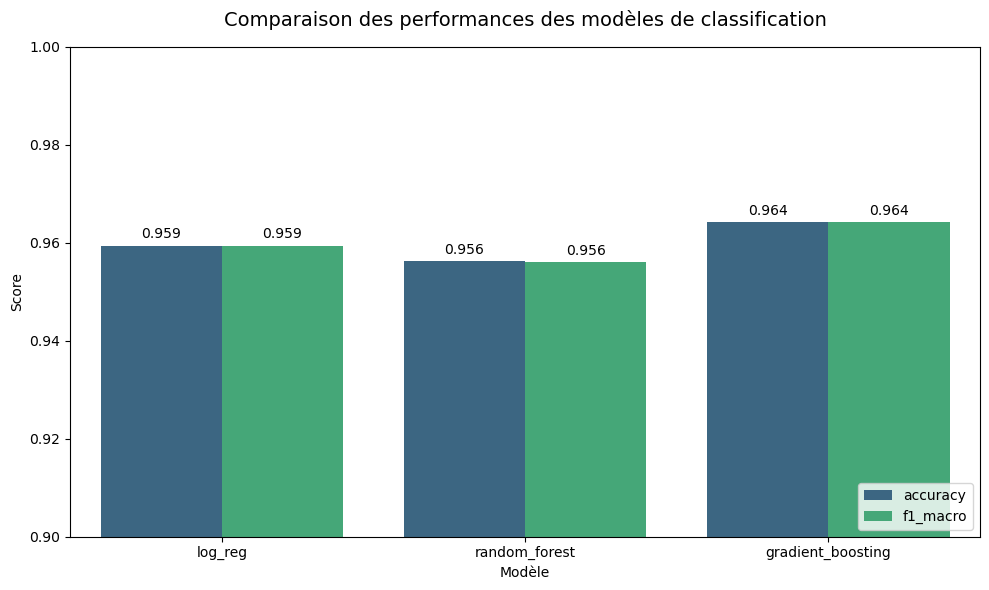

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Préparation des données pour le graphique
df_plot = df_metrics.melt(
    id_vars="model", 
    value_vars=["accuracy", "f1_macro"], 
    var_name="Métrique", 
    value_name="Score"
)

# Création du graphique en barres
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_plot, x="model", y="Score", hue="Métrique", palette="viridis")

plt.title("Comparaison des performances des modèles de classification", fontsize=14, pad=15)
plt.ylim(0.9, 1.0)  # On zoome sur le haut car les scores sont > 0.95
plt.ylabel("Score")
plt.xlabel("Modèle")

# Ajout des valeurs exactes au-dessus des barres
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha="center", va="center", 
                xytext=(0, 8), 
                textcoords="offset points",
                fontsize=10)

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()